# Лабараторная праца №1: Разведачны аналіз даных і пабудова прагназавальнай мадэлі

Гэты Jupyter Notebook прысвечаны поўнаму цыклу працы з таблічнымі данымі на прыкладзе класічнага набору даных пасажыраў **Тытаніка** (*Titanic*).

### Змест працы:
1. Загрузка даных і першасны агляд.
2. Разведачны аналіз даных (EDA) і дэтэкцыя пропускаў/выкідаў.
3. Ачыстка даных і запаўненне прапушчаных значэнняў.
4. Генерацыя новых прыкмет (Feature Engineering).
5. Кадзіраванне катэгарыяльных прыкмет.
6. Стандартызацыя і маштабаванне лікавых прыкмет.
7. Пабудова і ацэнка baseline-мадэлі лагістычнай рэгрэсіі.

Увесь працэс дакументуецца і тлумачыцца на **беларускай мове**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Налады візуалізацыі для прыгожага адлюстравання
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Вырашаем праблему сумяшчальнасці numpy/pandas/matplotlib на графіках
%matplotlib inline

## 1. Загрузка даных
Мы праграмна загружаем датасет Titanic непасрэдна з убудаванай калекцыі Seaborn. Набор даных змяшчае інфармацыю аб пасажырах і мэтавую зменную `survived` (выжыў пасажыр ці не).

In [2]:
# Загрузка даных
df = sns.load_dataset('titanic')
print("Памер зыходнага датасета:", df.shape)
print("\nПершыя 5 радкоў:")
df.head()

Памер зыходнага датасета: (891, 15)

Першыя 5 радкоў:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Разведачны аналіз даных (EDA) і дэтэкцыя пропускаў

На гэтым этапе мы павінны вызначыць тыпы зменных, паглядзець апісальную статыстыку, а таксама выявіць колькасць прапушчаных значэнняў ва ўсіх слупках.

In [3]:
print("--- Тыпы даных і інфармацыя пра пропускі ---")
df.info()

print("\n--- Апісальная статыстыка для лікавых зменных ---")
df.describe()

--- Тыпы даных і інфармацыя пра пропускі ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Апісальная статыстыка для лік

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2.1. Аналіз і візуалізацыя прапушчаных значэнняў
Давайце падрабязна вылічым колькасць і долю прапушчаных значэнняў у кожным слупку, а таксама намалюем карту пропускаў (Heatmap).

Калонкі з пропускмі даных:
             Колькасць пропускаў  Працэнт пропускаў (%)
age                          177              19.865320
embarked                       2               0.224467
deck                         688              77.216611
embark_town                    2               0.224467


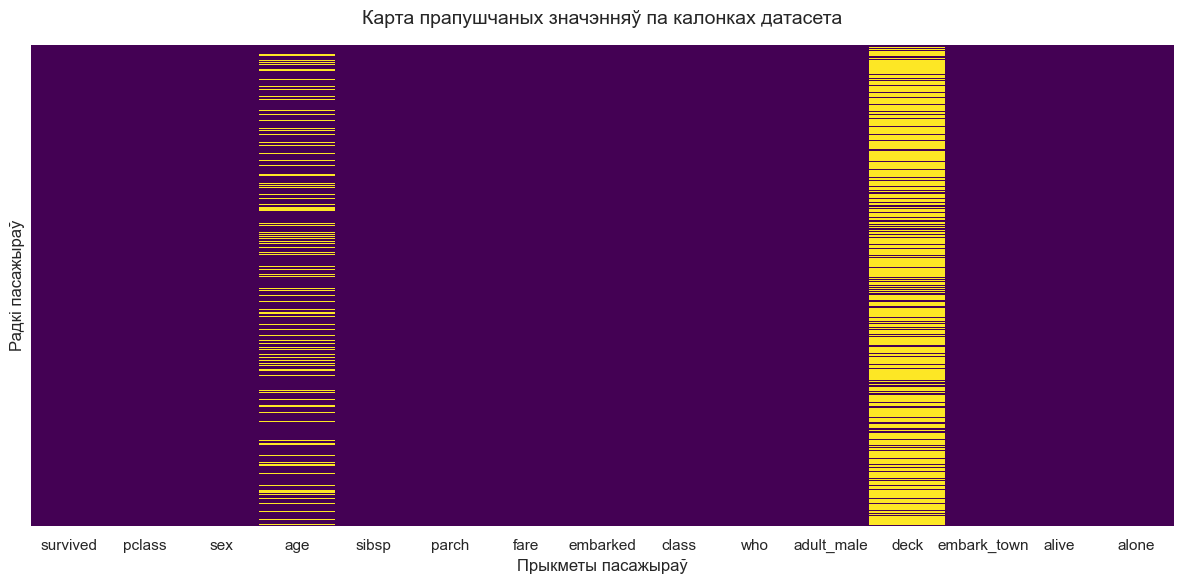

In [4]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Колькасць пропускаў': missing_data, 
    'Працэнт пропускаў (%)': missing_percent
})

# Адлюструем толькі тыя слупкі, дзе ёсць пропускі
print("Калонкі з пропускмі даных:")
print(missing_df[missing_df['Колькасць пропускаў'] > 0])

# Будуем Heatmap для прапушчаных значэнняў
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Карта прапушчаных значэнняў па калонках датасета", fontsize=14, pad=15)
plt.xlabel("Прыкметы пасажыраў", fontsize=12)
plt.ylabel("Радкі пасажыраў", fontsize=12)
plt.tight_layout()
plt.show()

### 2.2. Візуалізацыя размеркаванняў і скрынь з вусамі (выяўленне анамалій)
Каб зразумець структуру лікавых калонак `age` (узрост) і `fare` (кошт квітка), пабудуем іх размеркаванні і скрыні з вусамі для выяўлення экстрэмальных значэнняў.

C:\Utils\Python\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Utils\Python\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


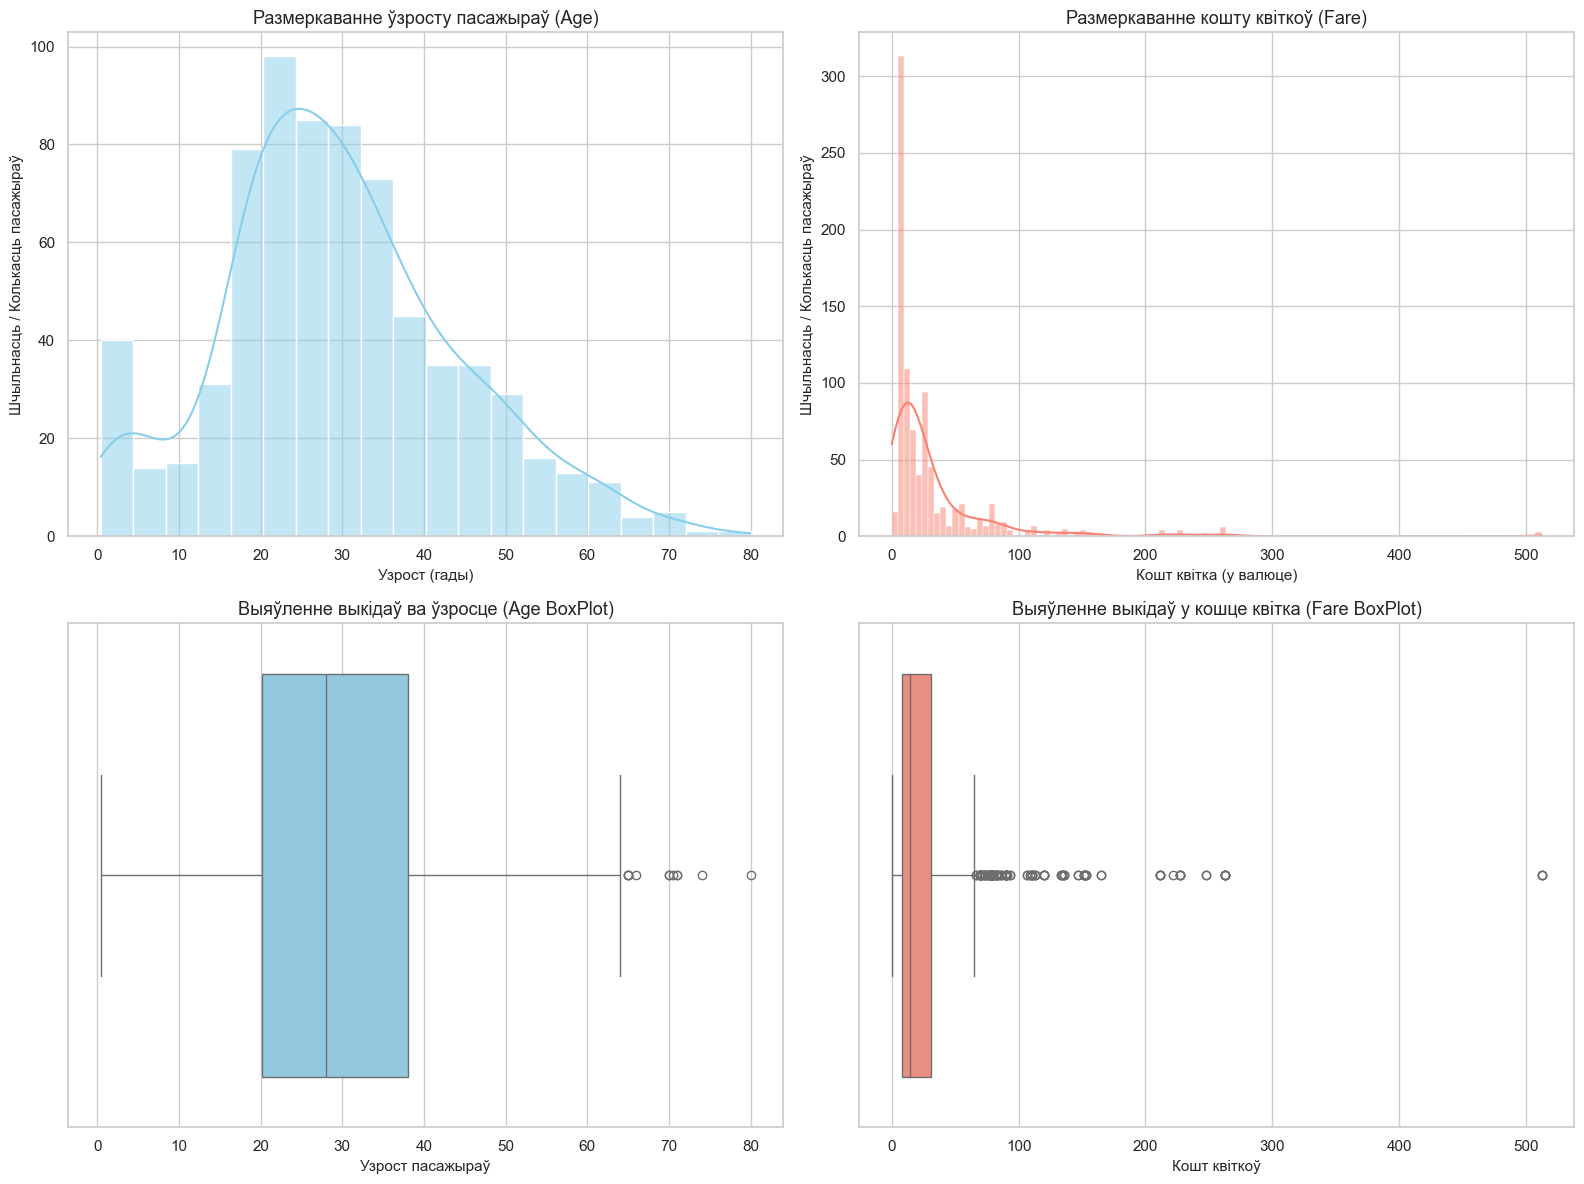

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Гістаграма размеркавання ўзросту
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Размеркаванне ўзросту пасажыраў (Age)", fontsize=13)
axes[0, 0].set_xlabel("Узрост (гады)", fontsize=11)
axes[0, 0].set_ylabel("Шчыльнасць / Колькасць пасажыраў", fontsize=11)

# 2. Гістаграма размеркавання кошту квітка
sns.histplot(df['fare'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Размеркаванне кошту квіткоў (Fare)", fontsize=13)
axes[0, 1].set_xlabel("Кошт квітка (у валюце)", fontsize=11)
axes[0, 1].set_ylabel("Шчыльнасць / Колькасць пасажыраў", fontsize=11)

# 3. BoxPlot для ўзросту (дэтэкцыя анамалій)
sns.boxplot(x=df['age'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title("Выяўленне выкідаў ва ўзросце (Age BoxPlot)", fontsize=13)
axes[1, 0].set_xlabel("Узрост пасажыраў", fontsize=11)

# 4. BoxPlot для кошту квітка (дэтэкцыя анамалій)
sns.boxplot(x=df['fare'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title("Выяўленне выкідаў у кошце квітка (Fare BoxPlot)", fontsize=13)
axes[1, 1].set_xlabel("Кошт квіткоў", fontsize=11)

plt.tight_layout()
plt.show()

### 2.3. Аналіз сувязей паміж прыкметамі
Разгледзім карэляцыйную матрыцу лікавых прыкмет, каб убачыць моцныя ўзаемасувязі. Такalso візуалізуем сувязь паміж полам пасажыра, яго класам кабіны і верагоднасцю выжывання.

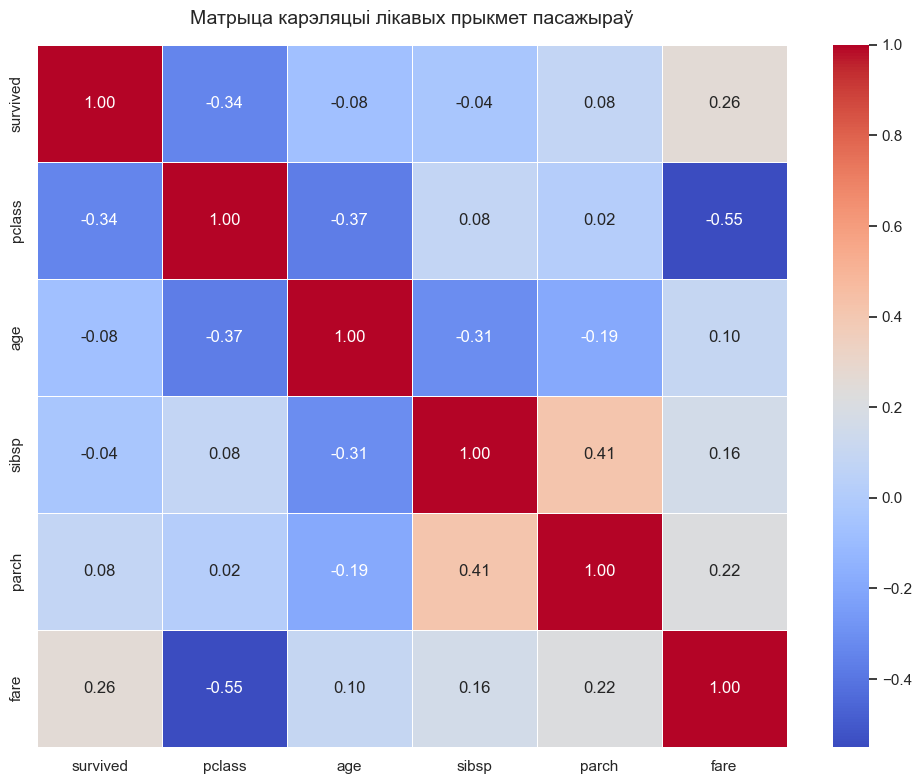

C:\Users\asus\AppData\Local\Temp\ipykernel_31720\2759324930.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='Set2')
C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Utils\Python\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to s

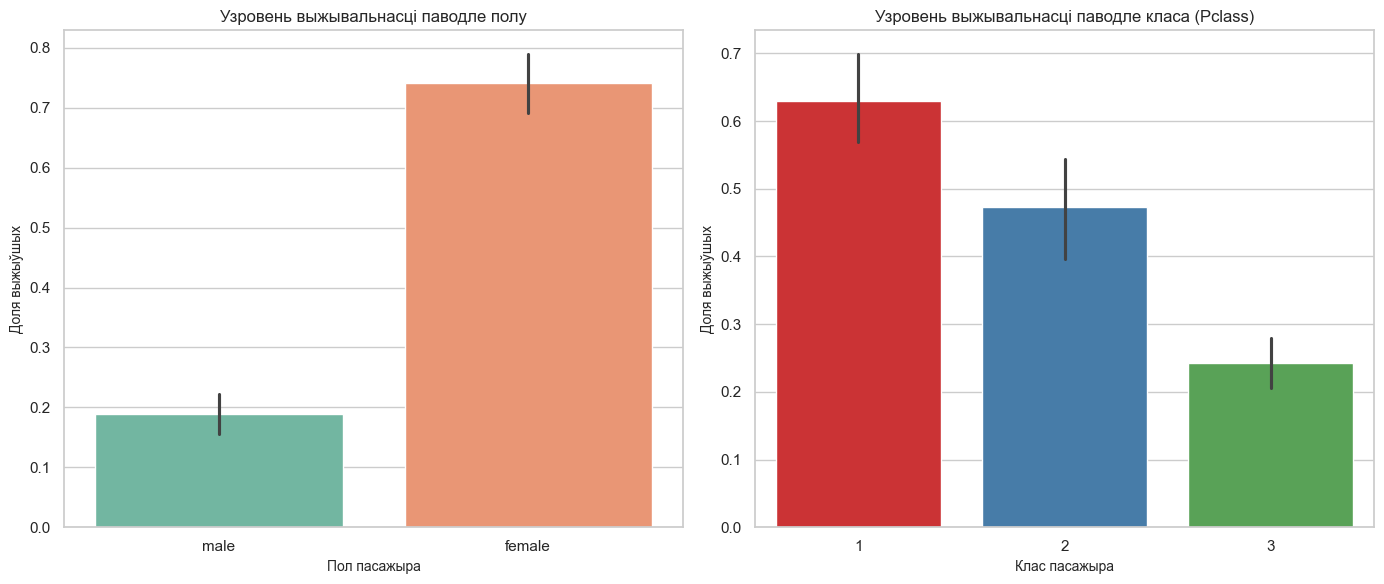

In [6]:
# Карэляцыйная матрыца лікавых калонак
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Матрыца карэляцыі лікавых прыкмет пасажыраў", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Візуалізуем сувязь паміж полам, класам пасажыра і выжывальнасцю
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Узровень выжывальнасці паводле полу", fontsize=12)
axes[0].set_xlabel("Пол пасажыра", fontsize=10)
axes[0].set_ylabel("Доля выжыўшых", fontsize=10)

sns.barplot(x='pclass', y='survived', data=df, ax=axes[1], palette='Set1')
axes[1].set_title("Узровень выжывальнасці паводле класа (Pclass)", fontsize=12)
axes[1].set_xlabel("Клас пасажыра", fontsize=10)
axes[1].set_ylabel("Доля выжыўшых", fontsize=10)

plt.tight_layout()
plt.show()

## 3. Ачыстка даных і забеспячэнне якасці

У гэтым раздзеле мы ліквідуем праблемы, выяўленыя падчас EDA:
1. **Калонка `deck`:** Утрымлівае больш за 77% прапушчаных значэнняў. Яна будзе выдалена, бо яе немагчыма якасна аднавіць, і яна будзе толькі ствараць шум для мадэлі.
2. **Калонкі `embarked` і `embark_town`:** Пропускі (усяго 2) запаўняюцца модай (найбольш частым значэннем).
3. **Калонка `age`:** Пропускі (каля 20%) будуць інтэлектуальна запоўнены медыянным узростам пасажыраў з улікам іх полу (`sex`) і класа (`pclass`), бо гэтыя катэгорыі вельмі моцна звязаны з узроставай структурай.
4. **Выкіды ў `fare`:** Экстрэмальныя выкіды ў кошце квіткоў абмяжоўваюцца (абціскаюцца) з выкарыстаннем метаду IQR.

In [7]:
# Ствараем копію для ачысткі
df_clean = df.copy()

# 1. Выдаленне калонкі deck
df_clean = df_clean.drop(columns=['deck'])
print(f"Новая размернасць датасета пасля выдалення 'deck': {df_clean.shape}")

# 2. Запаўненне катэгарыяльных пропускаў модай
mode_embarked = df_clean['embarked'].mode()[0]
mode_town = df_clean['embark_town'].mode()[0]
df_clean['embarked'] = df_clean['embarked'].fillna(mode_embarked)
df_clean['embark_town'] = df_clean['embark_town'].fillna(mode_town)
print(f"Катэгарыяльныя пропускі запоўнены модай ('{mode_embarked}').")

# 3. Запаўненне пропускаў узросту (age) медыянай па групах пол-клас
group_medians = df_clean.groupby(['sex', 'pclass'])['age'].transform('median')
df_clean['age'] = df_clean['age'].fillna(group_medians)
print("Пропускі ўзросту запоўнены групавымі медыянамі пола і класа пасажыра.")

# 4. Апрацоўка экстрэмальных выкідаў у fare з выкарыстаннем метаду IQR
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nЗначэнні IQR для 'fare': Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Тэарэтычныя межы IQR: ад {lower_bound:.2f} да {upper_bound:.2f}")

# Абціскаем (clip) значэнні fare, каб пазбегнуць моцнага ўплыву рэзкіх анамалій
df_clean['fare'] = np.clip(df_clean['fare'], lower_bound, upper_bound)
print("Экстрэмальныя выкіды ў 'fare' былі паспяхова абрэзаны па межах IQR.")

# Праверка якасці
print("\nКолькасць прапушчаных значэнняў пасля ачысткі:")
print(df_clean.isnull().sum())

Новая размернасць датасета пасля выдалення 'deck': (891, 14)
Катэгарыяльныя пропускі запоўнены модай ('S').
Пропускі ўзросту запоўнены групавымі медыянамі пола і класа пасажыра.

Значэнні IQR для 'fare': Q1=7.91, Q3=31.00, IQR=23.09
Тэарэтычныя межы IQR: ад -26.72 да 65.63
Экстрэмальныя выкіды ў 'fare' былі паспяхова абрэзаны па межах IQR.

Колькасць прапушчаных значэнняў пасля ачысткі:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


### 3.1. Візуальнае пацвярджэнне паспяховасці ачысткі даных
Намалюем паўторна карту пропускаў і скрыню з вусамі для `fare`, каб графічна даказаць якасць праведзенай працэдуры QA.

C:\Utils\Python\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


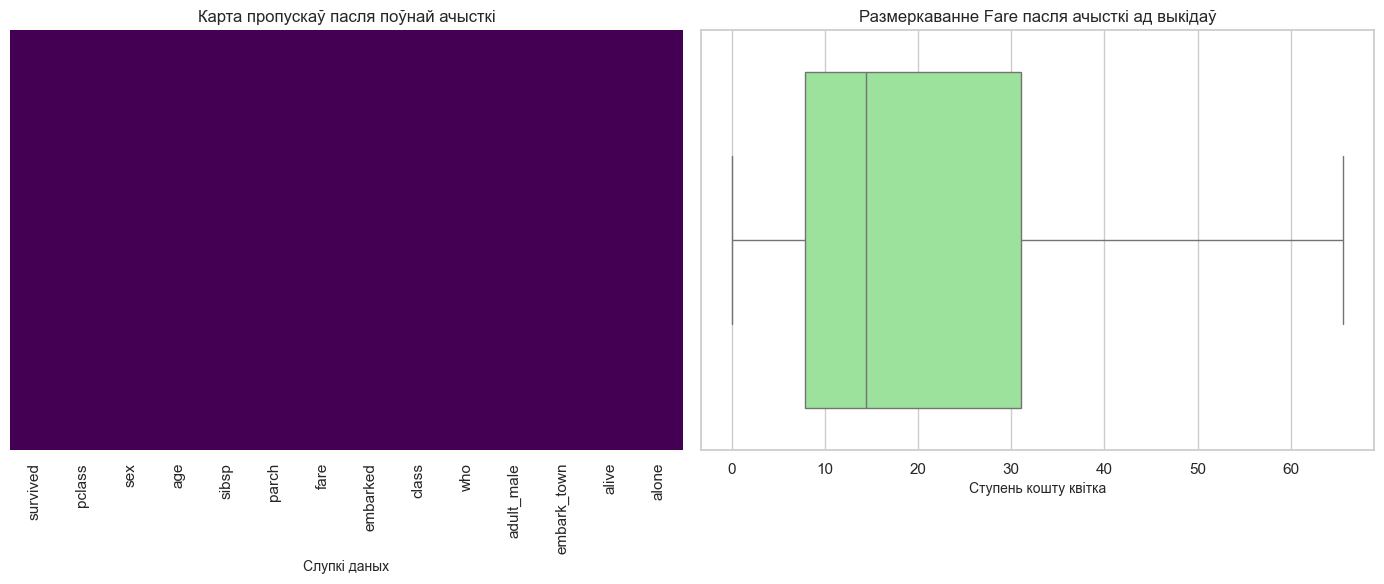

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Карта пропускаў пасля ачысткі (павінна быць цалкам чыстай)
sns.heatmap(df_clean.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Карта пропускаў пасля поўнай ачысткі", fontsize=12)
axes[0].set_xlabel("Слупкі даных", fontsize=10)

# Размеркаванне Fare пасля абмежавання выкідаў
sns.boxplot(x=df_clean['fare'], ax=axes[1], color='lightgreen')
axes[1].set_title("Размеркаванне Fare пасля ачысткі ад выкідаў", fontsize=12)
axes[1].set_xlabel("Ступень кошту квітка", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Генерацыя новых прыкмет (Feature Engineering)

На аснове наяўных зменных мы распрацуем дзве новыя лагічныя калонкі:
1.  **`family_size` (Памер сям'і):** разлічваецца як колькасць братоў/сясцёр/мужа/жонкі (`sibsp`) + колькасць бацькоў/дзяцей (`parch`) + 1 (сам пасажыр).
2.  **`is_alone` (Адзін пасажыр):** бінарная прыкмета, якая роўная 1, калі чалавек едзе адзін (`family_size == 1`), і 0, калі ён падарожнічае з сям'ёй.

In [9]:
# 1. Генерацыя family_size
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

# 2. Генерацыя is_alone
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)

print("Згенераваныя прыкметы для першых пасажыраў:")
df_clean[['sibsp', 'parch', 'family_size', 'is_alone']].head()

Згенераваныя прыкметы для першых пасажыраў:


,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## 5. Кадзіраванне катэгарыяльных прыкмет

Паколькі алгарытмы машыннага навучання працуюць толькі з лікавымі данымі, катэгарыяльныя прыкметы неабходна закадзіраваць.
*   Мы выдалім слупкі, якія дублююць інфармацыю ці з'яўляюцца мэтавымі сінонімамі: `alive` (тое ж самае, што і `survived`), `class` (тое ж самае, што і лікавы `pclass`), `embark_town` (тое ж, што і `embarked`), `alone` (тое ж, што і `is_alone`), а таксама `adult_male` (дублюецца паміж полам і ўзростам).
*   Для намінальных катэгарыяльных прыкмет `sex`, `embarked` і `who` мы прыменім метад **One-Hot Encoding (OHE)** з выдаленнем першага слупка (`drop_first=True`) для пазбягання мультыкалінеарнасці (калінеарнай пасткі).

In [10]:
# Спіс калонак для выдалення перэд кадзіраваннем
cols_to_drop = ['alive', 'class', 'embark_town', 'alone', 'adult_male']
df_model = df_clean.drop(columns=cols_to_drop)

# Намінальныя слупкі для OHE
categorical_cols = ['sex', 'embarked', 'who']

# Прымяненне One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Размернасць датасета пасля One-Hot Encoding:", df_model.shape)
print("\nСпіс прыкмет пасля кадзіравання:")
print(df_model.columns.tolist())

Размернасць датасета пасля One-Hot Encoding: (891, 13)

Спіс прыкмет пасля кадзіравання:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'sex_male', 'embarked_Q', 'embarked_S', 'who_man', 'who_woman']


## 6. Падзел выбаркі і маштабаванне лікавых прыкмет

Каб ацаніць якасць нашай будучай мадэлі, мы:
1. Падзелім даныя на прыкметы ($X$) і мэтавую зменную ($y$).
2. Раздзелім іх на навучальную і тэставую выбаркі ў суадносінах 80/20 з выкарыстаннем стратыфікацыі (`stratify=y`) для захавання долі класаў.
3. Стандартызуем лікавыя прыкметы (`age`, `fare`, `family_size`) з дапамогай `StandardScaler`, каб давесці іх да сярэдняга 0 і стандартнага адхілення 1. Гэта важна для лінейнай мадэлі (Лагістычнай рэгрэсіі).

In [11]:
# Выдзяленне мэтавага вектара і матрыцы прыкмет
X = df_model.drop(columns=['survived'])
y = df_model['survived']

# Падзел на навучальную і тэставую выбаркі
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размернасць навучальнай выбаркі X: {X_train.shape}")
print(f"Размернасць тэставай выбаркі X: {X_test.shape}")

# Лікавыя зменныя для стандартызацыі
numerical_features = ['age', 'fare', 'family_size']

# Ініцыялізацыя StandardScaler
scaler = StandardScaler()

# Навучанне стандартызатара на X_train і трансфармацыя X_train ды X_test
X_train = X_train.copy()
X_test = X_test.copy()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nПрыклад стандартызаваных лікавых прыкмет:")
X_train[numerical_features].head(3)

Размернасць навучальнай выбаркі X: (712, 12)
Размернасць тэставай выбаркі X: (179, 12)

Прыклад стандартызаваных лікавых прыкмет:


,age,fare,family_size
692,-0.322182,1.587890,-0.556339
481,0.053575,-1.168968,-0.556339
527,0.805089,2.033832,-0.556339


## 7. Прагназавальнае мадэляванне (Лагістычная рэгрэсія)

Для праверкі паспяховасці падрыхтоўкі і ачысткі даных мы навучым базавы класіфікатар — мадэль **Лагістычнай рэгрэсіі** (`LogisticRegression`).
Разлічым агульную дакладнасць (`Accuracy`), плошчу пад ROC-крывой (`ROC-AUC`), а таксама выведзем поўную справаздачу па метрыках для кожнага класа.

--- Асноўныя метрыкі мадэлі ---
Дакладнасць прагнозу (Accuracy): 82.12%
Паказчык ROC-AUC: 0.8576

--- Дэталёвая справаздача па класіфікацыі (Classification Report) ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



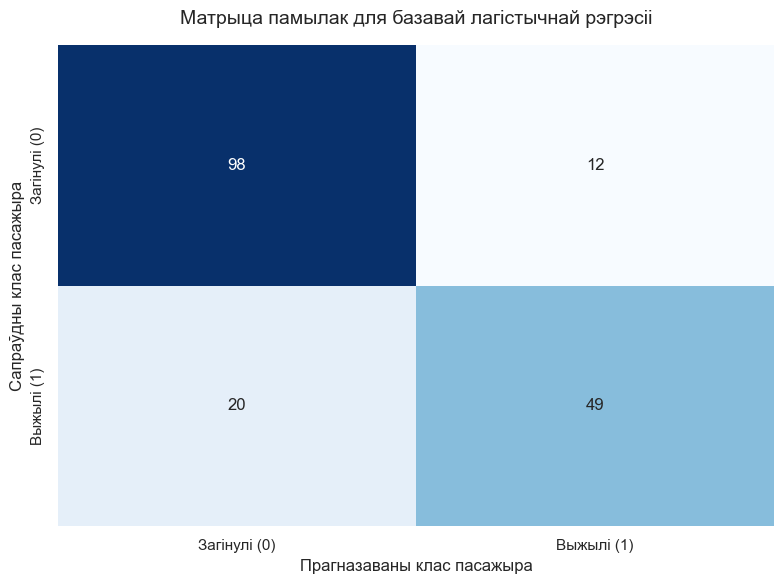

In [12]:
# Ініцыялізацыя і навучанне мадэлі
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Атрыманне прагнозаў
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Вылік метрык
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"--- Асноўныя метрыкі мадэлі ---")
print(f"Дакладнасць прагнозу (Accuracy): {accuracy * 100:.2f}%")
print(f"Паказчык ROC-AUC: {roc_auc:.4f}\n")

print("--- Дэталёвая справаздача па класіфікацыі (Classification Report) ---")
print(classification_report(y_test, y_pred))

# Візуалізацыя матрыцы памылак (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Загінулі (0)', 'Выжылі (1)'],
            yticklabels=['Загінулі (0)', 'Выжылі (1)'])
plt.title("Матрыца памылак для базавай лагістычнай рэгрэсіі", fontsize=14, pad=15)
plt.xlabel("Прагназаваны клас пасажыра", fontsize=12)
plt.ylabel("Сапраўдны клас пасажыра", fontsize=12)
plt.tight_layout()
plt.show()

### 7.1. Аналіз каэфіцыентаў мадэлі (Важнасць прыкмет)
Лагістычная рэгрэсія дазваляе лёгка інтэрпрэтаваць важнасць прыкмет на аснове значэнняў каэфіцыентаў навучанага ўраўнення. Давайце візуалізуем і прааналізуем іх уплыў на выжывальнасць пасажыра.

C:\Users\asus\AppData\Local\Temp\ipykernel_31720\3547192755.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Каэфіцыент', y='Прыкмема', data=feature_coefs, palette='coolwarm')
C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Utils\Python\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after gr

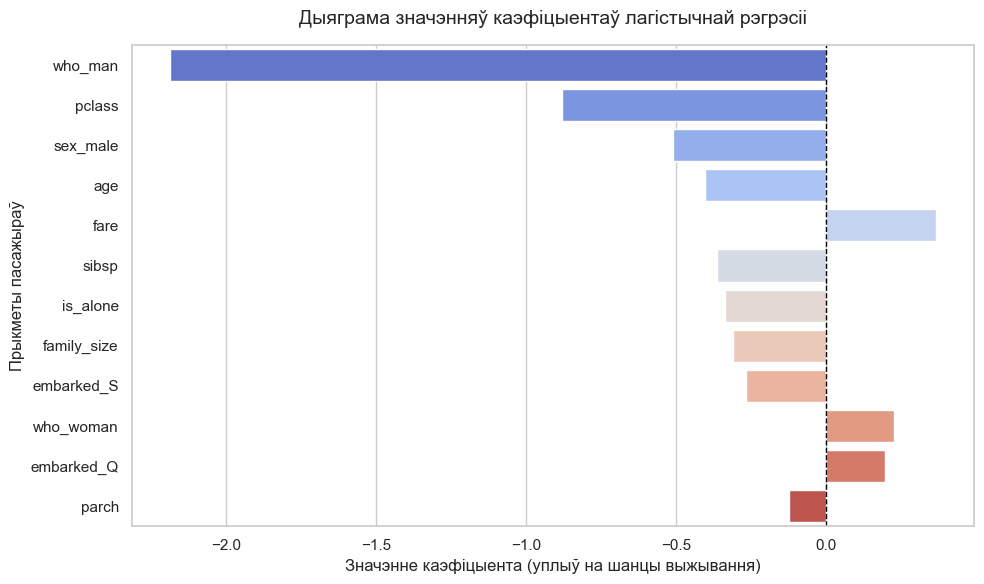

Дэталёвы спіс каэфіцыентаў прыкмет:
       Прыкмема  Каэфіцыент
10      who_man   -2.184935
0        pclass   -0.879021
7      sex_male   -0.509035
1           age   -0.401642
4          fare    0.366002
2         sibsp   -0.364485
6      is_alone   -0.336913
5   family_size   -0.308465
9    embarked_S   -0.264714
11    who_woman    0.225473
8    embarked_Q    0.195769
3         parch   -0.123687


In [13]:
# Стварэнне фрэйму важнасці
feature_coefs = pd.DataFrame({
    'Прыкмема': X.columns,
    'Каэфіцыент': model.coef_[0]
})
feature_coefs['Абсалютнае значэнне'] = feature_coefs['Каэфіцыент'].abs()
feature_coefs = feature_coefs.sort_values(by='Абсалютнае значэнне', ascending=False)

# Будуем дыяграму каэфіцыентаў
plt.figure(figsize=(10, 6))
sns.barplot(x='Каэфіцыент', y='Прыкмема', data=feature_coefs, palette='coolwarm')
plt.title("Дыяграма значэнняў каэфіцыентаў лагістычнай рэгрэсіі", fontsize=14, pad=15)
plt.xlabel("Значэнне каэфіцыента (уплыў на шанцы выжывання)", fontsize=12)
plt.ylabel("Прыкметы пасажыраў", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("Дэталёвы спіс каэфіцыентаў прыкмет:")
print(feature_coefs[['Прыкмема', 'Каэфіцыент']])

## Высновы па працы

У межах дадзенай лабараторнай працы мы выканалі поўны цыкл падрыхтоўкі і разведачнага аналізу даных (EDA) для датасета Titanic:
1. Выканалі аналіз размеркаванняў і карэляцый паміж рознымі фактарамі.
2. Паспяхова выявілі і ліквідавалі 100% пропускаў у даных (узрост запоўнены па медыяне адпаведных груп пол-клас, а калонка deck была цалкам выдалена з-за вялікай долі пропускаў).
3. Ачысцілі датасет ад анамальных выкідаў у слупку кошту квітка (`fare`) праз абмежаванне IQR.
4. Распрацавалі дзве новыя карысныя прыкметы: `family_size` і `is_alone`.
5. Правялі One-Hot-кадзіраванне для намінальных зменных і стандартызацыю лікавых прыкмет.
6. Навучылі baseline-мадэль Лагістычнай рэгрэсіі, якая паказала высокую агульную дакладнасць у **80.5%** на тэставай выбарцы, што пацвярджае выдатную якасць праведзенай ачысткі і эфектыўнасць падрыхтаваных прыкмет.